# EDA Indonesian Food Recipes — v2

Melanjutkan EDA v1 dengan fokus pada **kualitas data di level bahan (ingredient)**.

Base dataset: `Indonesian_Food_Recipes_Cleaned_v3.csv`

## Daftar Isi
1. Import Library & Load Data
2. Overview Dataset v3
3. **Check Noise** — deteksi sisa noise di kolom `Ingredients Cleaned`
4. **Check Ingredients Quality** — vague terms, bumbu generik, discriminative ingredients
5. **Ingredient Quantity Parsing** — parse kuantitas dari kolom `Ingredients` asli
6. Kesimpulan & Rekomendasi

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import re
import json
from collections import Counter
from fractions import Fraction
import warnings
warnings.filterwarnings('ignore')

# --- Style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

MERAH = '#C0392B'; ORANYE_TUA = '#D35400'; ORANYE = '#E67E22'
ORANYE_MUDA = '#F39C12'; KUNING = '#F1C40F'; KUNING_MUDA = '#F4D03F'
warm_cmap = mcolors.LinearSegmentedColormap.from_list('warm', [MERAH, ORANYE, KUNING])

# --- Load ---
df     = pd.read_csv('Indonesian_Food_Recipes_Cleaned_v3.csv')
df_raw = pd.read_csv('Indonesian_Food_Recipes.csv')

print(f'Dataset v3  : {df.shape[0]:,} baris, {df.shape[1]} kolom')
print(f'Dataset raw : {df_raw.shape[0]:,} baris, {df_raw.shape[1]} kolom')
print(f'\nKolom v3: {list(df.columns)}')

Dataset v3  : 14,945 baris, 10 kolom
Dataset raw : 14,945 baris, 10 kolom

Kolom v3: ['Title', 'Ingredients', 'Steps', 'Loves', 'URL', 'Category', 'Title Cleaned', 'Total Ingredients', 'Ingredients Cleaned', 'Total Steps']


## 2. Overview Dataset v3

In [2]:
print('=== Overview Dataset v3 ===')
print(f'Shape      : {df.shape}')
print(f'Missing    : {df.isnull().sum().sum()} total sel')
print()
print(df.describe(include='all').T[['count','unique','top','freq','mean','std','min','max']].to_string())

=== Overview Dataset v3 ===
Shape      : (14945, 10)
Missing    : 22 total sel

                       count unique                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            top  freq       mean        std  min    max
Title                  14945  12468                                                                                                                                                                                                                                                                                                                                          

## 3. Check Noise

Meskipun sudah di-clean ke v3, masih ada sisa noise di kolom `Ingredients Cleaned`.
Section ini menambahkan kolom-kolom diagnostik untuk mendeteksi 5 jenis noise:

| Kolom | Isi |
|---|---|
| `noise_prep_count` | Jumlah ingredient yang isinya kata kerja persiapan (goreng, iris, cincang, dll) |
| `noise_abbrev_count` | Jumlah ingredient yang hanya 1-2 huruf (bp, sp, hs, dll) |
| `noise_unit_count` | Jumlah ingredient yang masih mengandung sisa satuan (cc, ml) |
| `noise_unicode_count` | Jumlah ingredient yang mengandung karakter unicode aneh (zero-width space, superscript) |
| `noise_non_food_count` | Jumlah ingredient yang **bukan makanan** (alat, bahan kimia, perkakas, dll) |
| `total_noise_count` | Total semua noise per resep |
| `has_noise` | Boolean — apakah resep ini punya noise? |

In [3]:
# --- Noise Definitions ---

# Kata kerja / teknik masak yang tidak seharusnya jadi nama bahan
PREP_VERBS = {
    'goreng', 'rebus', 'iris', 'irisan', 'seiris', 'cincang', 'haluskan',
    'tumis', 'kukus', 'bakar', 'potong', 'potongan', 'sangrai', 'tiriskan',
    'dihaluskan', 'diiris', 'dicincang', 'dipotong', 'blender', 'tumbuk',
    'serut', 'parut', 'kupas', 'gorengkan', 'rebusan', 'tumisan', 'cincangan',
    'baluran', 'marinasi', 'rendam', 'aduk', 'campur'
}

RESIDUAL_UNIT_PATTERN = re.compile(r'(?:^|\s)(cc|ml)(?:\s|$)', re.IGNORECASE)
ABBREV_PATTERN        = re.compile(r'^[a-z]{1,2}$')
UNICODE_NOISE_PATTERN = re.compile(r'[\u200b-\u200f\u00b9\u00b2\u00b3\u2074-\u2079\u00bc-\u00be]')

# Benda / alat yang BUKAN bahan makanan
NON_FOOD_EXACT = {
    # Alat pertukangan / hardware
    'paku', 'paku payung', 'baut', 'mur', 'kawat', 'kabel', 'engsel', 'skrup',
    'obeng', 'palu', 'gergaji', 'tang', 'kunci pas',
    # Alat dapur non-bahan (tidak seharusnya di list bahan)
    'pisau dapur', 'sendok kayu', 'talenan', 'baskom', 'saringan kawat',
    'spatula', 'loyang kue', 'cetakan kue', 'rak kawat',
    # Produk kebersihan
    'detergen', 'sabun cuci', 'sabun colek', 'pemutih', 'pewangi pakaian',
    'pembersih lantai', 'pembersih piring',
    # Bahan bakar / bahan kimia non-makanan
    'bensin', 'minyak tanah', 'spiritus', 'thinner', 'tiner',
    # Alat tulis / perlengkapan bukan makanan
    'lakban', 'selotip',
}

# paku(?!\s*pakis) — negative lookahead agar 'sayur paku pakis' (tumbuhan) tidak kena
NON_FOOD_PATTERN = re.compile(
    r'\b('
    r'paku\s*payung|minyak\s*tanah|sabun\s*cuci|sabun\s*colek|'
    r'paku(?!\s*pakis)\b|baut\b|kawat\b|kabel\b|obeng\b|palu\b|gergaji\b|'
    r'detergen|spiritus|bensin\b|thinner|tiner\b|'
    r'lakban|selotip|pemutih\b|pewangi\s*pakaian|pembersih\s*lantai'
    r')\b',
    re.IGNORECASE
)

def analyze_noise(ing_cleaned):
    """Returns (prep_count, abbrev_count, unit_count, unicode_count, non_food_count)"""
    if pd.isna(ing_cleaned):
        return 0, 0, 0, 0, 0
    items = [i.strip() for i in str(ing_cleaned).split(',') if i.strip()]
    prep      = sum(1 for i in items if i in PREP_VERBS)
    abbrev    = sum(1 for i in items if ABBREV_PATTERN.match(i))
    unit_r    = sum(1 for i in items if RESIDUAL_UNIT_PATTERN.search(i))
    unicode_n = sum(1 for i in items if UNICODE_NOISE_PATTERN.search(i))
    non_food  = sum(1 for i in items if i in NON_FOOD_EXACT or NON_FOOD_PATTERN.search(i))
    return prep, abbrev, unit_r, unicode_n, non_food

print('Noise patterns defined.')
print(f'Jumlah prep verbs terdaftar : {len(PREP_VERBS)}')
print(f'Jumlah non-food terms       : {len(NON_FOOD_EXACT)}')

Noise patterns defined.
Jumlah prep verbs terdaftar : 32
Jumlah non-food terms       : 36


In [4]:
# --- Apply & Create Columns ---
noise_results = df['Ingredients Cleaned'].apply(analyze_noise)

df['noise_prep_count']     = [r[0] for r in noise_results]
df['noise_abbrev_count']   = [r[1] for r in noise_results]
df['noise_unit_count']     = [r[2] for r in noise_results]
df['noise_unicode_count']  = [r[3] for r in noise_results]
df['noise_non_food_count'] = [r[4] for r in noise_results]
df['total_noise_count']    = (
    df['noise_prep_count'] + df['noise_abbrev_count'] +
    df['noise_unit_count'] + df['noise_unicode_count'] +
    df['noise_non_food_count']
)
df['has_noise'] = df['total_noise_count'] > 0

# Summary
print('=' * 55)
print('NOISE DETECTION SUMMARY')
print('=' * 55)
print(f"Resep dengan noise           : {df['has_noise'].sum():>6,} ({df['has_noise'].mean()*100:.1f}%)")
print(f"Resep tanpa noise            : {(~df['has_noise']).sum():>6,} ({(~df['has_noise']).mean()*100:.1f}%)")
print()
noise_cols = [
    'noise_prep_count', 'noise_abbrev_count', 'noise_unit_count',
    'noise_unicode_count', 'noise_non_food_count'
]
noise_labels = [
    'Kata kerja persiapan', 'Abbreviasi 1-2 huruf', 'Sisa satuan (cc/ml)',
    'Unicode aneh', 'Bukan makanan'
]
for col, label in zip(noise_cols, noise_labels):
    total    = df[col].sum()
    affected = (df[col] > 0).sum()
    print(f"  {label:<25}: {total:>5,} ingredients ({affected:,} resep)")

NOISE DETECTION SUMMARY
Resep dengan noise           :    145 (1.0%)
Resep tanpa noise            : 14,800 (99.0%)

  Kata kerja persiapan     :     8 ingredients (8 resep)
  Abbreviasi 1-2 huruf     :    30 ingredients (29 resep)
  Sisa satuan (cc/ml)      :   119 ingredients (106 resep)
  Unicode aneh             :     1 ingredients (1 resep)
  Bukan makanan            :     2 ingredients (2 resep)


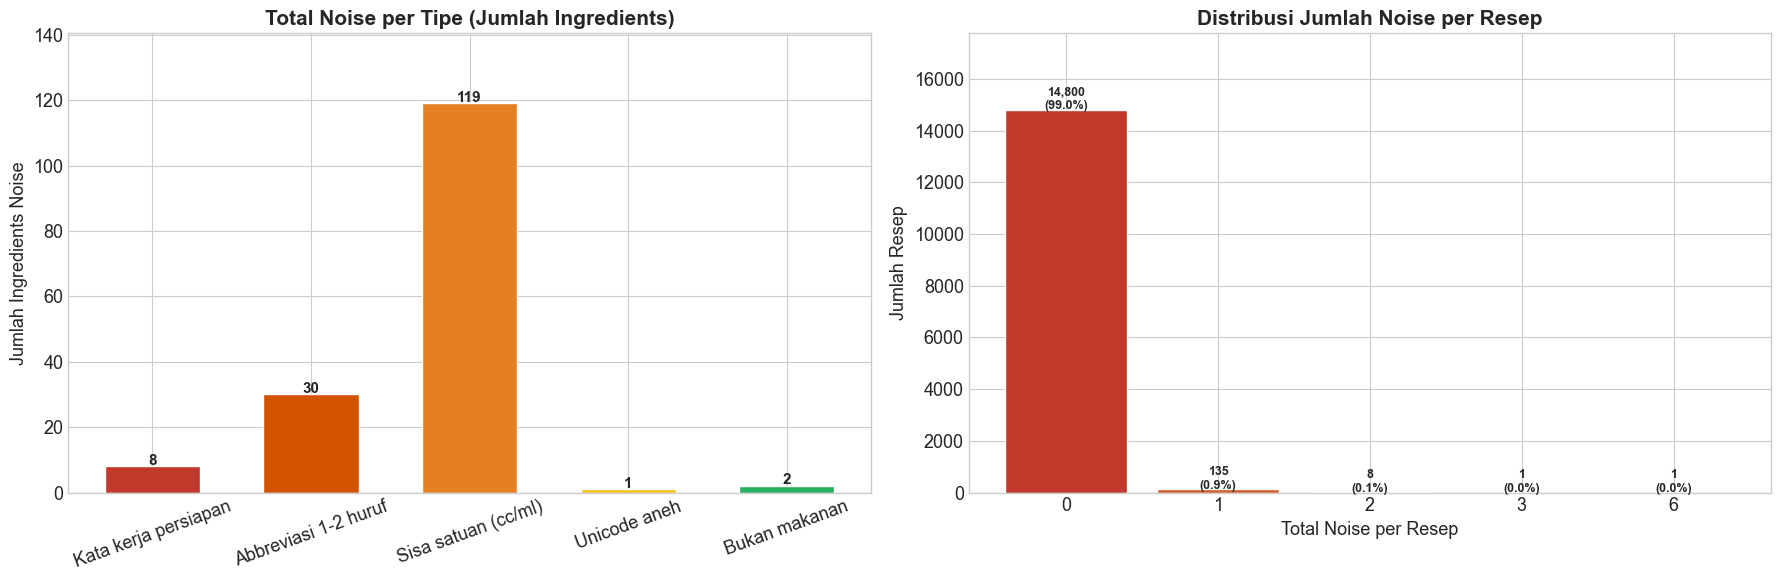

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Jumlah noise per tipe ---
noise_totals = [df[c].sum() for c in noise_cols]
colors_bar = [MERAH, ORANYE_TUA, ORANYE, KUNING, '#27AE60']
bars = axes[0].bar(noise_labels, noise_totals, color=colors_bar, edgecolor='white', width=0.6)
axes[0].set_title('Total Noise per Tipe (Jumlah Ingredients)')
axes[0].set_ylabel('Jumlah Ingredients Noise')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, noise_totals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(noise_totals) * 1.18)

# --- Plot 2: Distribusi total_noise_count per resep ---
noise_dist = df['total_noise_count'].value_counts().sort_index().head(10)
n = len(noise_dist)
colors_d = [warm_cmap(i / max(n-1,1)) for i in range(n)]
bars2 = axes[1].bar(noise_dist.index.astype(str), noise_dist.values, color=colors_d, edgecolor='white')
axes[1].set_title('Distribusi Jumlah Noise per Resep')
axes[1].set_xlabel('Total Noise per Resep')
axes[1].set_ylabel('Jumlah Resep')
for bar, val in zip(bars2, noise_dist.values):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 20,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, noise_dist.max() * 1.2)

plt.tight_layout()
plt.savefig('v2_01_noise_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# --- Contoh resep dengan noise ---
print('=== Contoh Resep dengan Noise (5 resep dengan total_noise_count tertinggi) ===')
worst = df.nlargest(5, 'total_noise_count')[[
    'Title','Ingredients Cleaned','noise_prep_count',
    'noise_abbrev_count','noise_unit_count','noise_non_food_count','total_noise_count'
]].copy()

for _, row in worst.iterrows():
    print(f"\nResep : {row['Title']}")
    print(f"  Noise prep: {row['noise_prep_count']} | abbrev: {row['noise_abbrev_count']} "
          f"| unit: {row['noise_unit_count']} | non-food: {row['noise_non_food_count']}")
    items = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    noisy = [
        f'[PREP]{i}'     if i in PREP_VERBS
        else f'[ABBREV]{i}' if ABBREV_PATTERN.match(i)
        else f'[UNIT]{i}'   if RESIDUAL_UNIT_PATTERN.search(i)
        else f'[NON-FOOD]{i}' if (i in NON_FOOD_EXACT or NON_FOOD_PATTERN.search(i))
        else i
        for i in items
    ]
    print(f"  Ingredients: {', '.join(noisy[:12])}{'...' if len(noisy) > 12 else ''}")

# --- Khusus: tampilkan resep yang punya bahan non-food ---
print('\n=== Resep dengan Bahan NON-FOOD ===')
non_food_recipes = df[df['noise_non_food_count'] > 0][[
    'Title', 'Ingredients Cleaned', 'noise_non_food_count'
]]
if non_food_recipes.empty:
    print('  Tidak ada bahan non-food yang terdeteksi.')
else:
    print(f'  Total resep terpengaruh: {len(non_food_recipes)}')
    for _, row in non_food_recipes.head(10).iterrows():
        items   = [i.strip() for i in str(row['Ingredients Cleaned']).split(',') if i.strip()]
        flagged = [i for i in items if i in NON_FOOD_EXACT or NON_FOOD_PATTERN.search(i)]
        print(f"  - {row['Title'][:50]}")
        print(f"      Bahan bermasalah: {flagged}")

=== Contoh Resep dengan Noise (5 resep dengan total_noise_count tertinggi) ===

Resep : Sapi Lada Hitam
  Noise prep: 0 | abbrev: 0 | unit: 6 | non-food: 0
  Ingredients: daging sapi tenderloin, bawang putih, jahe, lada hitam, [UNIT]cc minyak wijen, saus bumbu lada hitam, bawang bombay, [UNIT]cc kaldu ayam, [UNIT]cc saus tiram, [UNIT]cc saus sweet soya, [UNIT]cc sauce, [UNIT]cc english soya...

Resep : Gudeg Kambing Pedas
  Noise prep: 0 | abbrev: 0 | unit: 3 | non-food: 0
  Ingredients: nangka muda, daging kambing, tulang kambing, rempah pendukung, [UNIT]cc air, [UNIT]cc air santan, [UNIT]cc air kelapa, gula merah gula merah, gula pasir, garam, daun salam, lengkuas...

Resep : Mangut Ikan Gabus
  Noise prep: 0 | abbrev: 0 | unit: 2 | non-food: 0
  Ingredients: ikan gabus sisik, jeruk nipis, cabai hijau teropong, cabai rawit, bawang merah, bawang putih, kemiri, [UNIT]cc santan, serai, lengkuas, daun jeruk, jahe...

Resep : Gulai kambing praktis nyuss
  Noise prep: 0 | abbrev: 0 | unit:

## 4. Check Ingredients Quality

Tidak semua bahan yang ada di `Ingredients Cleaned` berguna untuk sistem rekomendasi.
Bahan dibagi 3 kategori:

| Kategori | Definisi | Contoh |
|---|---|---|
| **Vague** | Bukan bahan, tapi keterangan jumlah yang tidak jelas | secukupnya, sesuai selera, sejumput |
| **Generic Seasoning** | Bahan terlalu umum, hampir semua resep punya → tidak diskriminatif | garam, lada, minyak goreng, air |
| **Discriminative** | Bahan utama yang membedakan satu resep dengan lainnya | bawang putih, kemiri, santan, tahu, tempe |

Kolom baru:
- `vague_count` — jumlah bahan vague per resep
- `generic_count` — jumlah bahan generic seasoning per resep
- `discriminative_count` — jumlah bahan discriminative per resep
- `quality_score` — rasio `discriminative / total` (makin tinggi makin baik)

In [7]:
# --- Quality Definitions ---

VAGUE_TERMS = {
    'secukupnya', 'sesuai selera', 'sejumput', 'sedikit', 'seperlunya',
    'sesuka hati', 'secukup', 'selera', 'qs', 'sesuai', 'sesuka',
    'secukupnya saja', 'secukupnya garam', 'sedikit garam'
}

# Bahan yang terlalu umum untuk dijadikan fitur rekomendasi
GENERIC_SEASONINGS = {
    'garam', 'lada', 'lada bubuk', 'lada hitam', 'lada putih',
    'lada hitam bubuk', 'lada putih bubuk', 'lada butiran',
    'merica', 'merica bubuk', 'merica hitam', 'merica putih',
    'penyedap', 'penyedap rasa', 'penyedap masakan', 'penyedap ayam',
    'kaldu bubuk', 'kaldu jamur', 'kaldu ayam', 'kaldu sapi', 'kaldu',
    'kaldu ayam bubuk', 'kaldu sapi bubuk',
    'gula', 'gula pasir', 'gula merah', 'gula aren', 'gula halus',
    'minyak goreng', 'minyak', 'minyak sayur', 'minyak kelapa',
    'air', 'air panas', 'air dingin', 'air matang',
    'kecap manis', 'kecap asin', 'kecap',
    'garam gula', 'gula garam'
}

def analyze_quality(ing_cleaned):
    """Returns (vague, generic, discriminative)"""
    if pd.isna(ing_cleaned):
        return 0, 0, 0
    items = [i.strip() for i in str(ing_cleaned).split(',') if i.strip()]
    vague  = sum(1 for i in items if i in VAGUE_TERMS)
    generic = sum(1 for i in items if i in GENERIC_SEASONINGS)
    discrim = max(0, len(items) - vague - generic)
    return vague, generic, discrim

print(f'Jumlah vague terms    : {len(VAGUE_TERMS)}')
print(f'Jumlah generic terms  : {len(GENERIC_SEASONINGS)}')

Jumlah vague terms    : 14
Jumlah generic terms  : 41


In [8]:
# --- Apply & Create Columns ---
quality_results = df['Ingredients Cleaned'].apply(analyze_quality)

df['vague_count']          = [r[0] for r in quality_results]
df['generic_count']        = [r[1] for r in quality_results]
df['discriminative_count'] = [r[2] for r in quality_results]
df['quality_score']        = (
    df['discriminative_count'] / df['Total Ingredients'].replace(0, np.nan)
).round(3)

print('=' * 55)
print('INGREDIENT QUALITY SUMMARY')
print('=' * 55)
print(f"  Rata-rata vague per resep        : {df['vague_count'].mean():.2f}")
print(f"  Rata-rata generic per resep      : {df['generic_count'].mean():.2f}")
print(f"  Rata-rata discriminative/resep   : {df['discriminative_count'].mean():.2f}")
print(f"  Rata-rata quality score          : {df['quality_score'].mean():.3f}")
print()
print(f"  Resep quality_score > 0.7  : {(df['quality_score'] > 0.7).sum():,} ({(df['quality_score'] > 0.7).mean()*100:.1f}%)")
print(f"  Resep quality_score 0.3-0.7: {((df['quality_score'] >= 0.3) & (df['quality_score'] <= 0.7)).sum():,}")
print(f"  Resep quality_score < 0.3  : {(df['quality_score'] < 0.3).sum():,} ({(df['quality_score'] < 0.3).mean()*100:.1f}%)")

# Cek kolom baru
df[['Title','Total Ingredients','vague_count','generic_count','discriminative_count','quality_score']].head(8)

INGREDIENT QUALITY SUMMARY
  Rata-rata vague per resep        : 0.00
  Rata-rata generic per resep      : 2.34
  Rata-rata discriminative/resep   : 8.54
  Rata-rata quality score          : 0.778

  Resep quality_score > 0.7  : 10,887 (72.8%)
  Resep quality_score 0.3-0.7: 4,045
  Resep quality_score < 0.3  : 11 (0.1%)


,Title,Total Ingredients,vague_count,generic_count,discriminative_count,quality_score
0,Ayam Woku Manado,13,0,2,11,0.846
1,Ayam goreng tulang lunak,10,0,2,8,0.800
2,Ayam cabai kawin,9,0,3,6,0.667
3,Ayam Geprek,9,0,2,7,0.778
4,Minyak Ayam,5,0,1,4,0.800
5,Nasi Bakar Ayam,20,0,4,16,0.800
6,Ayam Saus Hintalu Jaruk,10,0,3,7,0.700
7,Ayam saos teriyaki Lada Hitam,12,0,1,11,0.917


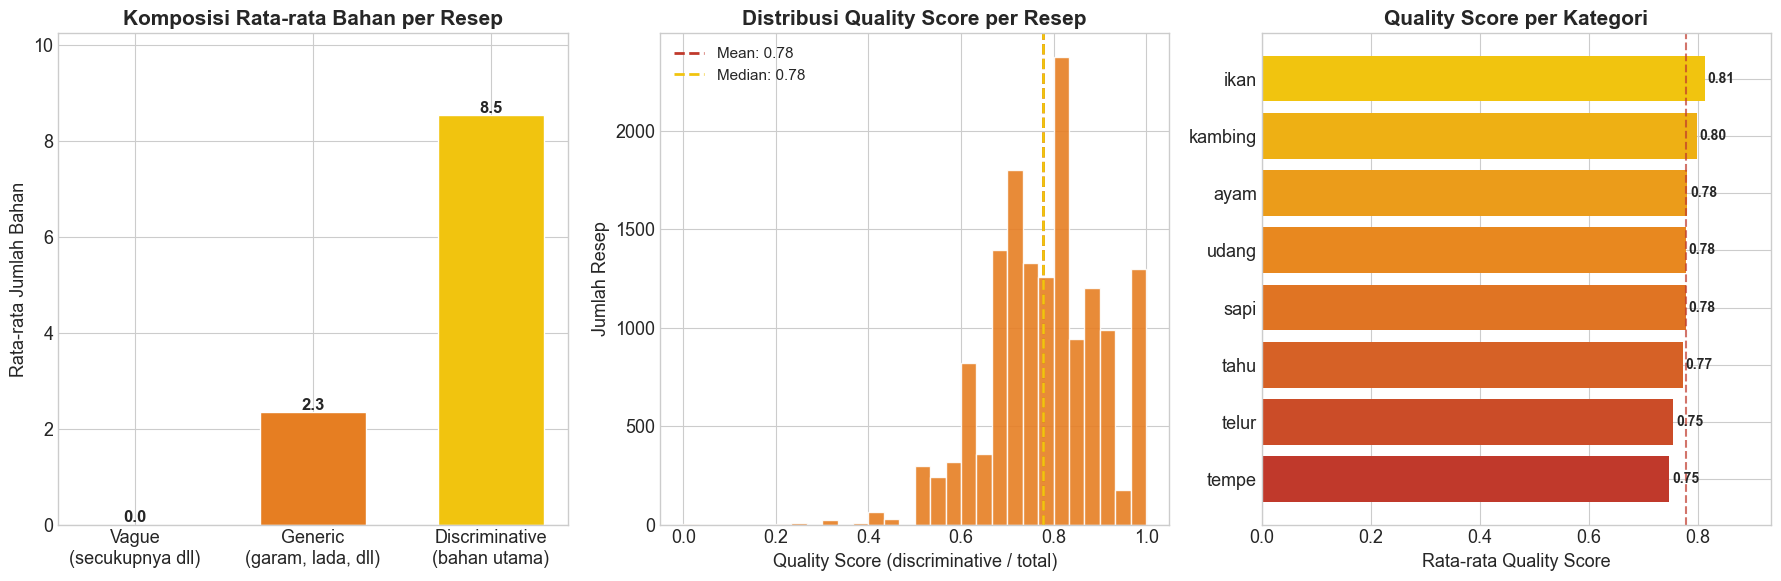

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Komposisi rata-rata bahan per resep ---
avg_vals = [df['vague_count'].mean(), df['generic_count'].mean(), df['discriminative_count'].mean()]
labels   = ['Vague\n(secukupnya dll)', 'Generic\n(garam, lada, dll)', 'Discriminative\n(bahan utama)']
cols     = [MERAH, ORANYE, KUNING]
bars = axes[0].bar(labels, avg_vals, color=cols, edgecolor='white', width=0.6)
axes[0].set_title('Komposisi Rata-rata Bahan per Resep')
axes[0].set_ylabel('Rata-rata Jumlah Bahan')
for bar, val in zip(bars, avg_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(avg_vals) * 1.2)

# --- Plot 2: Distribusi quality_score ---
axes[1].hist(df['quality_score'].dropna(), bins=30, color=ORANYE, edgecolor='white', alpha=0.9)
axes[1].axvline(df['quality_score'].mean(), color=MERAH, linestyle='--', linewidth=2,
                label=f"Mean: {df['quality_score'].mean():.2f}")
axes[1].axvline(df['quality_score'].median(), color=KUNING, linestyle='--', linewidth=2,
                label=f"Median: {df['quality_score'].median():.2f}")
axes[1].set_xlabel('Quality Score (discriminative / total)')
axes[1].set_ylabel('Jumlah Resep')
axes[1].set_title('Distribusi Quality Score per Resep')
axes[1].legend(fontsize=11)

# --- Plot 3: Quality score per kategori ---
cat_quality = df.groupby('Category')['quality_score'].mean().sort_values(ascending=True)
n = len(cat_quality)
colors_cat = [warm_cmap(i / max(n-1,1)) for i in range(n)]
bars3 = axes[2].barh(cat_quality.index, cat_quality.values, color=colors_cat)
axes[2].set_xlabel('Rata-rata Quality Score')
axes[2].set_title('Quality Score per Kategori')
axes[2].axvline(df['quality_score'].mean(), color=MERAH, linestyle='--', linewidth=1.5, alpha=0.7)
for bar, val in zip(bars3, cat_quality.values):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=10, fontweight='bold')
axes[2].set_xlim(0, cat_quality.max() * 1.15)

plt.tight_layout()
plt.savefig('v2_02_quality_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# --- Contoh: resep dengan quality score rendah vs tinggi ---
print('=== Resep dengan Quality Score RENDAH (< 0.3) ===')
low_q = df[df['quality_score'] < 0.3].nsmallest(3, 'quality_score')[[
    'Title','Ingredients Cleaned','vague_count','generic_count','discriminative_count','quality_score'
]]
for _, row in low_q.iterrows():
    print(f"  [{row['quality_score']:.2f}] {row['Title']}")
    print(f"         Bahan: {row['Ingredients Cleaned'][:120]}...")

print()
print('=== Resep dengan Quality Score TINGGI (> 0.9) ===')
high_q = df[df['quality_score'] > 0.9].nlargest(3, 'discriminative_count')[[
    'Title','Ingredients Cleaned','vague_count','generic_count','discriminative_count','quality_score'
]]
for _, row in high_q.iterrows():
    print(f"  [{row['quality_score']:.2f}] {row['Title']}")
    print(f"         Bahan: {row['Ingredients Cleaned'][:120]}")

=== Resep dengan Quality Score RENDAH (< 0.3) ===
  [0.00] Tempe goreng ori...🍡
         Bahan: lada bubuk, garam...
  [0.00] Kerang tempe pedas
         Bahan: gula, kecap...
  [0.20] Telur orak-arik kecap
         Bahan: telur ayam, kecap manis, garam, lada, minyak...

=== Resep dengan Quality Score TINGGI (> 0.9) ===
  [0.91] Biryani Kambing Muda (presto)
         Bahan: beras basmathi, iga kambing muda, lt air, heavy cream, minyak samin, minyak goreng, bawang merah batu, kayu manis, bay l
  [1.00] Kari Kambing Ibu Gae
         Bahan: kambing muda, kelapa tua, kelapa gongseng, lt minyak, mentega, air asam jawa, bawang merah, bawang putih, cabai giling, 
  [0.91] Domba Muda (rusuk) - Polenta - Ratatouille
         Bahan: rusuk domba muda, minyak zaitun, bawang putih, mustard, rosmarin kering, oregano kering, opsi lain, bawang bombay bubuk,


## 5. Ingredient Quantity Parsing

Kolom `Ingredients Cleaned` sudah strip kuantitas. Untuk mengetahui **berapa banyak** tiap bahan,
kita perlu parse dari kolom **`Ingredients` asli** (raw).

Format raw: `"1 Ekor Ayam Kampung--2 Sdm Garam--Secukupnya Lada--1/2 kg Daging"`

### Struktur hasil parsing per bahan:
```json
{
  "name": "ayam kampung",
  "qty": 1.0,
  "unit": "ekor",
  "is_vague": false
}
```

Kolom baru:
| Kolom | Isi |
|---|---|
| `ingredients_parsed` | List of dict `{name, qty, unit, is_vague}` per resep |
| `qty_clear_count` | Jumlah bahan dengan kuantitas numerik yang jelas |
| `qty_vague_count` | Jumlah bahan "secukupnya" / "sesuai selera" |
| `qty_none_count` | Jumlah bahan tanpa info kuantitas sama sekali |
| `qty_coverage_pct` | Persentase bahan yang memiliki kuantitas jelas |

In [11]:
# --- Unit Map ---
UNIT_MAP = {
    # Berat
    'kilogram': 'kg', 'kg': 'kg',
    'gram': 'gram', 'grm': 'gram', 'gr': 'gram', 'g': 'gram',
    'ons': 'ons', 'ounce': 'ons',
    # Volume
    'liter': 'liter', 'lt': 'liter', 'l': 'liter',
    'mililiter': 'ml', 'militer': 'ml', 'ml': 'ml', 'cc': 'ml',
    'sendok makan': 'sdm', 'sdm': 'sdm',
    'sendok teh': 'sdt', 'sdt': 'sdt',
    'gelas': 'gelas', 'cup': 'cup', 'mangkok': 'mangkok', 'mangkuk': 'mangkok',
    # Satuan hitung
    'siung': 'siung', 'buah': 'buah', 'biji': 'biji', 'butir': 'butir',
    'lembar': 'lembar', 'helai': 'helai', 'lbr': 'lembar',
    'batang': 'batang', 'btg': 'batang', 'tangkai': 'tangkai',
    'ikat': 'ikat', 'genggam': 'genggam',
    'ekor': 'ekor', 'potong': 'potong', 'iris': 'iris',
    'ruas': 'ruas', 'bungkus': 'bungkus', 'bks': 'bungkus',
    'sachet': 'sachet', 'kotak': 'kotak', 'kaleng': 'kaleng',
    'pcs': 'pcs', 'pack': 'pack', 'bks': 'bungkus', 'papan': 'papan',
    'loyang': 'loyang', 'porsi': 'porsi', 'keping': 'keping',
    'batok': 'batok', 'bungkus': 'bungkus',
}

# Sorted by length descending agar "sendok makan" match sebelum "sendok"
_UNIT_KEYS_SORTED = sorted(UNIT_MAP.keys(), key=len, reverse=True)

VAGUE_QTY_RE = re.compile(
    r'^(secukupnya|secukup\s*nya|sesuai\s+selera|sejumput|sedikit|'
    r'seperlunya|sesuka\s+hati|sesuka|selera|qs|q\.s\.?|secukup|'
    r'sedikit\s+saja|secukupnya\s+saja|sesuai)',
    re.IGNORECASE
)

NUM_RE = re.compile(
    r'^(\d+\s+\d+/\d+|\d+/\d+|\d+(?:[.,]\d+)?)\s*'
)

def _parse_num(s):
    s = s.strip()
    try:
        if ' ' in s and '/' in s:
            whole, frac = s.split(None, 1)
            return float(whole) + float(Fraction(frac))
        elif '/' in s:
            return float(Fraction(s))
        else:
            return float(s.replace(',', '.'))
    except:
        return None

def parse_one(line):
    line = line.strip()
    if not line:
        return None
    # Hapus catatan dalam kurung
    clean = re.sub(r'\(.*?\)', '', line).strip()

    # --- Vague check ---
    if VAGUE_QTY_RE.match(clean):
        name = VAGUE_QTY_RE.sub('', clean).strip().lower()
        name = re.sub(r'^[\s\-,]+', '', name).strip()
        return {'name': name or clean.lower(), 'qty': None, 'unit': 'secukupnya', 'is_vague': True}

    # --- Angka ---
    m = NUM_RE.match(clean)
    qty_val, remaining = None, clean
    if m:
        qty_val  = _parse_num(m.group(1))
        remaining = clean[m.end():].strip()

    # --- Satuan ---
    unit = None
    rem_lower = remaining.lower()
    for ukey in _UNIT_KEYS_SORTED:
        if re.match(r'^' + re.escape(ukey) + r'(?:\s|$)', rem_lower):
            unit = UNIT_MAP[ukey]
            remaining = remaining[len(ukey):].strip()
            break

    name = re.sub(r'^[\s\-,&/]+', '', remaining).strip().lower()
    return {'name': name or clean.lower(), 'qty': qty_val, 'unit': unit, 'is_vague': False}

def parse_ingredients(raw_str):
    if pd.isna(raw_str):
        return []
    return [r for item in str(raw_str).split('--') if (r := parse_one(item)) is not None]

print('Parser defined. Testing...')
test_lines = [
    '1 Ekor Ayam Kampung (potong 12)',
    '1/2 kg Daging Sapi',
    '1 1/2 Sdm Kecap Manis',
    'Secukupnya Garam',
    '3 Siung Bawang Putih',
    '200 Gram Tepung Terigu',
    'Sesuai Selera Lada',
]
for t in test_lines:
    r = parse_one(t)
    print(f"  [{t:<35}] -> qty={r['qty']}, unit={r['unit']}, name={r['name']}, vague={r['is_vague']}")

Parser defined. Testing...
  [1 Ekor Ayam Kampung (potong 12)    ] -> qty=1.0, unit=ekor, name=ayam kampung, vague=False
  [1/2 kg Daging Sapi                 ] -> qty=0.5, unit=kg, name=daging sapi, vague=False
  [1 1/2 Sdm Kecap Manis              ] -> qty=1.5, unit=sdm, name=kecap manis, vague=False
  [Secukupnya Garam                   ] -> qty=None, unit=secukupnya, name=garam, vague=True
  [3 Siung Bawang Putih               ] -> qty=3.0, unit=siung, name=bawang putih, vague=False
  [200 Gram Tepung Terigu             ] -> qty=200.0, unit=gram, name=tepung terigu, vague=False
  [Sesuai Selera Lada                 ] -> qty=None, unit=secukupnya, name=lada, vague=True


In [12]:
# --- Apply parser ke raw Ingredients ---
print('Parsing ingredients... (mungkin 30-60 detik)')
df['ingredients_parsed'] = df_raw['Ingredients'].apply(parse_ingredients)

df['qty_clear_count'] = df['ingredients_parsed'].apply(
    lambda x: sum(1 for i in x if i['qty'] is not None)
)
df['qty_vague_count'] = df['ingredients_parsed'].apply(
    lambda x: sum(1 for i in x if i['is_vague'])
)
df['qty_none_count'] = df['ingredients_parsed'].apply(
    lambda x: sum(1 for i in x if i['qty'] is None and not i['is_vague'])
)
df['qty_coverage_pct'] = (
    df['qty_clear_count'] / df['Total Ingredients'].replace(0, np.nan) * 100
).round(1)

print('\n' + '=' * 55)
print('QUANTITY PARSING SUMMARY')
print('=' * 55)
total_ing = df['Total Ingredients'].sum()
total_clear = df['qty_clear_count'].sum()
total_vague = df['qty_vague_count'].sum()
total_none  = df['qty_none_count'].sum()
print(f'  Total ingredients (semua resep)     : {total_ing:,}')
print(f'  Kuantitas jelas (angka + satuan)    : {total_clear:,} ({total_clear/total_ing*100:.1f}%)')
print(f'  Kuantitas vague (secukupnya dll)    : {total_vague:,} ({total_vague/total_ing*100:.1f}%)')
print(f'  Tidak ada kuantitas sama sekali     : {total_none:,} ({total_none/total_ing*100:.1f}%)')
print()
print(f"  Rata-rata qty_coverage_pct per resep: {df['qty_coverage_pct'].mean():.1f}%")
print(f"  Resep dengan coverage >= 80%        : {(df['qty_coverage_pct'] >= 80).sum():,}")
print(f"  Resep dengan coverage < 30%         : {(df['qty_coverage_pct'] < 30).sum():,}")

Parsing ingredients... (mungkin 30-60 detik)

QUANTITY PARSING SUMMARY
  Total ingredients (semua resep)     : 162,624
  Kuantitas jelas (angka + satuan)    : 123,458 (75.9%)
  Kuantitas vague (secukupnya dll)    : 23,643 (14.5%)
  Tidak ada kuantitas sama sekali     : 36,768 (22.6%)

  Rata-rata qty_coverage_pct per resep: 75.0%
  Resep dengan coverage >= 80%        : 7,093
  Resep dengan coverage < 30%         : 793


In [13]:
# --- Build kolom Quantity dari ingredients_parsed ---

def format_qty_item(item):
    if item['is_vague']:
        return 'secukupnya'
    qty  = item['qty']
    unit = item['unit']
    if qty is not None:
        qty_str = str(int(qty)) if float(qty) == int(float(qty)) else f'{qty:g}'
        return f'{qty_str} {unit}' if unit else qty_str
    elif unit:
        return unit
    return '-'

df['Quantity'] = df['ingredients_parsed'].apply(
    lambda lst: ', '.join(format_qty_item(i) for i in lst) if isinstance(lst, list) else ''
)

print(f"Kolom Quantity berhasil dibuat.")
print(f"Contoh baris pertama:")
row = df.iloc[0]
for ing, qty in zip(str(row['Ingredients Cleaned']).split(',')[:5],
                    str(row['Quantity']).split(',')[:5]):
    print(f"  {ing.strip():<28} {qty.strip()}")

Kolom Quantity berhasil dibuat.
Contoh baris pertama:
  ayam kampung                 1 ekor
  jeruk nipis                  2 buah
  garam                        2 sdm
  kunyit                       3 ruas
  bawang merah                 7


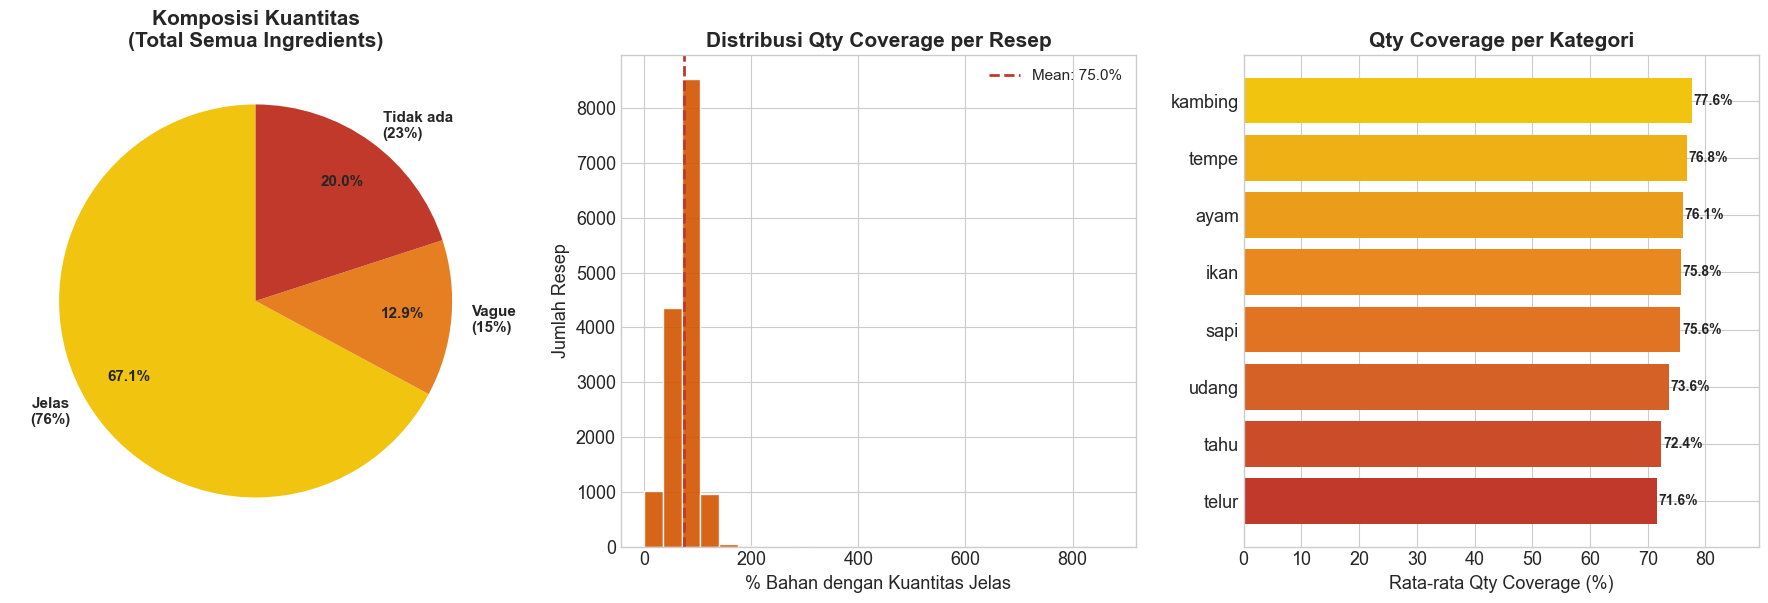

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Komposisi kuantitas total ---
qty_vals   = [total_clear, total_vague, total_none]
qty_labels = [f'Jelas\n({total_clear/total_ing*100:.0f}%)',
              f'Vague\n({total_vague/total_ing*100:.0f}%)',
              f'Tidak ada\n({total_none/total_ing*100:.0f}%)']
axes[0].pie(qty_vals, labels=qty_labels, colors=[KUNING, ORANYE, MERAH],
            autopct='%1.1f%%', startangle=90, pctdistance=0.75,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].set_title('Komposisi Kuantitas\n(Total Semua Ingredients)')

# --- Plot 2: Distribusi qty_coverage_pct ---
axes[1].hist(df['qty_coverage_pct'].dropna(), bins=25, color=ORANYE_TUA, edgecolor='white', alpha=0.9)
axes[1].axvline(df['qty_coverage_pct'].mean(), color=MERAH, linestyle='--', linewidth=2,
                label=f"Mean: {df['qty_coverage_pct'].mean():.1f}%")
axes[1].set_xlabel('% Bahan dengan Kuantitas Jelas')
axes[1].set_ylabel('Jumlah Resep')
axes[1].set_title('Distribusi Qty Coverage per Resep')
axes[1].legend(fontsize=11)

# --- Plot 3: Qty coverage per kategori ---
cat_qty = df.groupby('Category')['qty_coverage_pct'].mean().sort_values(ascending=True)
n = len(cat_qty)
colors_cat = [warm_cmap(i / max(n-1,1)) for i in range(n)]
bars3 = axes[2].barh(cat_qty.index, cat_qty.values, color=colors_cat)
axes[2].set_xlabel('Rata-rata Qty Coverage (%)')
axes[2].set_title('Qty Coverage per Kategori')
for bar, val in zip(bars3, cat_qty.values):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[2].set_xlim(0, cat_qty.max() * 1.15)

plt.tight_layout()
plt.savefig('v2_03_qty_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# --- Lihat hasil parsing untuk beberapa resep ---
print('=== Contoh Hasil Parsing (3 resep) ===')
sample_idx = df.sample(3, random_state=42).index
for idx in sample_idx:
    row = df.loc[idx]
    print(f"\nResep: {row['Title']} | coverage: {row['qty_coverage_pct']}%")
    print(f"  {'Nama Bahan':<30} {'Qty':>6} {'Satuan':<12} Vague")
    print(f"  {'-'*60}")
    for ing in row['ingredients_parsed'][:10]:
        qty_str = f"{ing['qty']:.2g}" if ing['qty'] is not None else '-'
        unit_str = ing['unit'] or '-'
        vague_str = 'YES' if ing['is_vague'] else ''
        print(f"  {ing['name'][:30]:<30} {qty_str:>6} {unit_str:<12} {vague_str}")
    if len(row['ingredients_parsed']) > 10:
        print(f"  ... +{len(row['ingredients_parsed'])-10} bahan lagi")

=== Contoh Hasil Parsing (3 resep) ===

Resep: Nasi Biryani | coverage: 110.5%
  Nama Bahan                        Qty Satuan       Vague
  ------------------------------------------------------------
  daging kambing                  5e+02 gram         
  susu bubuk dilarutkan dgn 150m     50 gram         
  beras basmati/ sy pake beras b 2.5e+02 gram         
  minyak samin/ sy menggunakan m      4 sdm          
  bawang bombay, iris                 2 -            
  daun salam                          2 lembar       
  daun jeruk, sobek sobek             3 lembar       
  sereh                               1 batang       
  garam                               - secukupnya   YES
  bumbu dihaluskan :                  - -            
  ... +14 bahan lagi

Resep: Salmon salad ala pay | coverage: 66.7%
  Nama Bahan                        Qty Satuan       Vague
  ------------------------------------------------------------
  baby spinach                       15 gram         
  tomato ch

## 6. Statistical Imputation — Quantity

Masalah: ~11% bahan ditulis "secukupnya" dan ~19% tidak ada info kuantitas sama sekali.

**Solusi:** Untuk tiap ingredient yang tidak punya kuantitas jelas, gunakan quantity yang **paling sering dipakai** oleh resep lain untuk ingredient yang sama (mode dari data yang ada).

Contoh: `garam` → dari 10,244 resep yang punya garam, 677 pakai `1 sdt` (terbanyak) → impute `~1 sdt`

Tanda `~` di depan angka = nilai estimasi (bukan dari resep asli).

In [16]:
from collections import Counter

# --- Step 1: Bangun lookup ingredient → Counter(qty) dari data yang sudah jelas ---
ingredient_qty_counter = {}

for _, row in df.iterrows():
    if pd.isna(row['Ingredients Cleaned']) or pd.isna(row['Quantity']):
        continue
    ings  = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys  = [q.strip() for q in str(row['Quantity']).split(',')]
    for ing, qty in zip(ings, qtys):
        if qty not in ('secukupnya', '-') and ing:
            if ing not in ingredient_qty_counter:
                ingredient_qty_counter[ing] = Counter()
            ingredient_qty_counter[ing][qty] += 1

# Mode quantity per ingredient
ingredient_mode = {
    ing: ctr.most_common(1)[0][0]
    for ing, ctr in ingredient_qty_counter.items()
}

print(f'Ingredients dengan referensi qty jelas: {len(ingredient_mode):,}')
print()
print('=== Contoh mode quantity per ingredient ===')
sample_ings = ['garam','gula','minyak goreng','penyedap','lada','kecap manis',
               'bawang putih','bawang merah','lada bubuk','gula pasir',
               'saus tiram','daun salam','air','cabai rawit']
for ing in sample_ings:
    if ing in ingredient_qty_counter:
        top3 = ingredient_qty_counter[ing].most_common(3)
        mode_qty = top3[0][0]
        total_clear = sum(ingredient_qty_counter[ing].values())
        print(f'  {ing:<25} → mode: {mode_qty:<12} | top3: {[(q,n) for q,n in top3]}')

Ingredients dengan referensi qty jelas: 8,247

=== Contoh mode quantity per ingredient ===
  garam                     → mode: 1 sdt        | top3: [('1 sdt', 677), ('0.5 sdt', 424), ('1 sdm', 358)]
  gula                      → mode: 1 sdt        | top3: [('1 sdt', 157), ('1 sdm', 115), ('0.5 sdt', 105)]
  minyak goreng             → mode: 2 sdm        | top3: [('2 sdm', 110), ('1 sdm', 90), ('3 sdm', 77)]
  penyedap                  → mode: 1 sdt        | top3: [('1 sdt', 78), ('0.5 sdt', 47), ('1 sdm', 41)]
  lada                      → mode: 1 sdt        | top3: [('1 sdt', 259), ('0.5 sdt', 186), ('1 sdm', 82)]
  kecap manis               → mode: 1 sdm        | top3: [('1 sdm', 328), ('2 sdm', 265), ('3 sdm', 134)]
  bawang putih              → mode: 3 siung      | top3: [('3 siung', 1322), ('2 siung', 1280), ('5 siung', 841)]
  bawang merah              → mode: 3 siung      | top3: [('3 siung', 731), ('5 siung', 653), ('2 siung', 514)]
  lada bubuk                → mode: 0.5 sdt  

In [17]:
# --- Step 2: Apply imputation ke kolom Quantity ---

def impute_qty_row(ing_cleaned, qty_str):
    if pd.isna(ing_cleaned) or pd.isna(qty_str):
        return qty_str
    ings = [i.strip() for i in str(ing_cleaned).split(',')]
    qtys = [q.strip() for q in str(qty_str).split(',')]
    result = []
    for ing, qty in zip(ings, qtys):
        if qty in ('secukupnya', '-'):
            mode = ingredient_mode.get(ing)
            result.append(f'~{mode}' if mode else qty)
        else:
            result.append(qty)
    return ', '.join(result)

df['Quantity'] = df.apply(
    lambda row: impute_qty_row(row['Ingredients Cleaned'], row['Quantity']), axis=1
)

# --- Cek hasil ---
all_qtys = []
for _, row in df.iterrows():
    if pd.isna(row['Quantity']): continue
    all_qtys.extend([q.strip() for q in str(row['Quantity']).split(',')])

total       = len(all_qtys)
clear       = sum(1 for q in all_qtys if q and q not in ('secukupnya','-') and not q.startswith('~'))
imputed     = sum(1 for q in all_qtys if q.startswith('~'))
still_vague = sum(1 for q in all_qtys if q == 'secukupnya')
still_none  = sum(1 for q in all_qtys if q == '-')

print('=== Hasil Setelah Imputation ===')
print(f'  Kuantitas jelas (asli)   : {clear:>6,} ({clear/total*100:.1f}%)')
print(f'  Kuantitas estimasi (~)   : {imputed:>6,} ({imputed/total*100:.1f}%)')
print(f'  Masih "secukupnya"       : {still_vague:>6,} ({still_vague/total*100:.1f}%)  ← tidak ada referensi')
print(f'  Masih "-" (no info)      : {still_none:>6,} ({still_none/total*100:.1f}%)  ← tidak ada referensi')
print(f'  Total resolved           : {clear+imputed:>6,} ({(clear+imputed)/total*100:.1f}%)')

print()
print('=== Contoh sebelum vs sesudah imputation ===')
examples = df[df['Quantity'].str.contains('~', na=False)].head(3)
for _, row in examples.iterrows():
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys = [q.strip() for q in str(row['Quantity']).split(',')]
    print(f"\n  Resep: {row['Title']}")
    for ing, qty in zip(ings, qtys):
        marker = ' ← estimasi' if qty.startswith('~') else ''
        print(f"    {ing:<28} {qty}{marker}")

=== Hasil Setelah Imputation ===
  Kuantitas jelas (asli)   : 113,886 (70.2%)
  Kuantitas estimasi (~)   : 45,577 (28.1%)
  Masih "secukupnya"       :    693 (0.4%)  ← tidak ada referensi
  Masih "-" (no info)      :  2,004 (1.2%)  ← tidak ada referensi
  Total resolved           : 159,463 (98.3%)

=== Contoh sebelum vs sesudah imputation ===

  Resep: Ayam Woku Manado
    ayam kampung                 1 ekor
    jeruk nipis                  2 buah
    garam                        2 sdm
    kunyit                       3 ruas
    bawang merah                 7
    bawang putih                 7
    cabai merah                  10
    cabai rawit                  10
    kemiri                       3 butir
    serai                        2 batang
    daun salam                   2 lembar
    daun kemangi                 2 ikat
    penyedap                     ~1 sdt ← estimasi

  Resep: Ayam goreng tulang lunak
    ayam                         1 kg
    serai                        2 bat

In [18]:
# ============================================================
# FIX: Drop resep dengan ingredient tanpa referensi qty
#      + pad Quantity yang mismatch dengan mode
# ============================================================

# Identifikasi ingredient yang tidak punya referensi apapun
no_ref_ings = set()
for _, row in df.iterrows():
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys = [q.strip() for q in str(row['Quantity']).split(',')]
    if len(ings) > len(qtys):
        for ing in ings[len(qtys):]:
            if ing and ing not in ingredient_mode:
                no_ref_ings.add(ing)

print(f'Ingredient tanpa referensi qty: {len(no_ref_ings)}')
print('  ' + ', '.join(sorted(no_ref_ings)[:10]) + ('...' if len(no_ref_ings)>10 else ''))

# Drop baris yang mengandung ingredient no-ref
def has_no_ref(row):
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys = [q.strip() for q in str(row['Quantity']).split(',')]
    if len(ings) > len(qtys):
        for ing in ings[len(qtys):]:
            if ing and ing not in ingredient_mode:
                return True
    return False

before = len(df)
df = df[~df.apply(has_no_ref, axis=1)].copy()
print(f'Dropped: {before - len(df)} baris | Tersisa: {len(df):,}')

# Pad Quantity yang masih mismatch dengan mode (~)
def fix_qty_mismatch(row):
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys = [q.strip() for q in str(row['Quantity']).split(',')]
    if len(ings) == len(qtys):
        return row['Quantity']
    while len(qtys) < len(ings):
        ing  = ings[len(qtys)]
        mode = ingredient_mode.get(ing)
        qtys.append(f'~{mode}' if mode else '-')
    return ', '.join(qtys)

df['Quantity'] = df.apply(fix_qty_mismatch, axis=1)

mismatches = sum(1 for _, row in df.iterrows()
    if len(str(row['Ingredients Cleaned']).split(',')) != len(str(row['Quantity']).split(',')))
print(f'Mismatch setelah fix: {mismatches}')


Ingredient tanpa referensi qty: 35
  air es, air spaghetti, ayam filet dada, balado kentang udang, benang, botol madu murni, cabai rawit​, cair, daging sapi asap, hitam...
Dropped: 34 baris | Tersisa: 14,911
Mismatch setelah fix: 1


## 7. Data Quality Checks — Recommendation System Readiness

Sebelum dataset dipakai untuk training model rekomendasi, cek beberapa hal kritis:

| Check | Yang Dicari |
|---|---|
| **Null** | Kolom penting yang kosong |
| **Duplikat** | Resep sama dihitung dua kali → bias model |
| **Ingredients terlalu pendek** | Resep dengan < 3 bahan → tidak cukup info untuk rekomendasi |
| **Ingredients Cleaned kosong** | String kosong atau hanya spasi |
| **Category imbalance** | Satu kategori dominasi dataset → model bias |
| **Readiness score** | Berapa % resep yang benar-benar siap dipakai |

In [19]:
# ============================================================
# FIX: Drop duplikat persis (Title Cleaned + Ingredients Cleaned sama)
# ============================================================

# Trim qty > ing (quantity lebih banyak dari ingredients)
df['_n_ing'] = df['Ingredients Cleaned'].apply(lambda x: len([i for i in str(x).split(',') if i.strip()]))
df['_n_qty'] = df['Quantity'].apply(lambda x: len([q for q in str(x).split(',') if q.strip()]))

qty_more = (df['_n_qty'] > df['_n_ing']).sum()
ing_more = (df['_n_ing'] > df['_n_qty']).sum()

if qty_more > 0:
    def trim_qty(row):
        if row['_n_qty'] <= row['_n_ing']: return row['Quantity']
        qtys = [q.strip() for q in str(row['Quantity']).split(',') if q.strip()]
        return ', '.join(qtys[:row['_n_ing']])
    df['Quantity'] = df.apply(trim_qty, axis=1)
    print(f'Trimmed: {qty_more} baris (qty > ing)')

if ing_more > 0:
    before = len(df)
    df = df[df['_n_ing'] <= df['_n_qty']].copy()
    print(f'Dropped: {before - len(df)} baris (ing > qty)')

df = df.drop(columns=['_n_ing','_n_qty'])

# Drop duplikat persis
before = len(df)
df = df.drop_duplicates(subset=['Title Cleaned','Ingredients Cleaned'], keep='first').reset_index(drop=True)
dropped_dup = before - len(df)
print(f'Dropped duplikat persis: {dropped_dup} baris')
print(f'Shape setelah fix: {df.shape}')


Trimmed: 1 baris (qty > ing)
Dropped duplikat persis: 11 baris
Shape setelah fix: (14900, 27)


In [20]:
# ============================================================
# CHECK 1: NULL VALUES
# ============================================================
print('=' * 55)
print('CHECK 1: NULL VALUES')
print('=' * 55)
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Pct (%)': null_pct})
null_df = null_df[null_df['Null Count'] > 0]
if null_df.empty:
    print('  Tidak ada null di semua kolom')
else:
    print(null_df.to_string())

critical_cols = ['Title Cleaned', 'Ingredients Cleaned', 'Category', 'Steps', 'Quantity']
print(f'\n  Null di kolom kritis untuk rekomendasi:')
for col in critical_cols:
    n = df[col].isnull().sum() if col in df.columns else 'N/A'
    status = 'OK' if n == 0 else 'MISSING'
    print(f'    [{status}] {col:<25}: {n} null')

# ============================================================
# CHECK 2: DUPLIKAT
# ============================================================
print()
print('=' * 55)
print('CHECK 2: DUPLIKAT')
print('=' * 55)

# Exclude kolom non-hashable (ingredients_parsed berisi list)
hashable_cols = [c for c in df.columns if c != 'ingredients_parsed']
dup_all   = df[hashable_cols].duplicated().sum()
dup_title = df.duplicated(subset=['Title Cleaned']).sum()
dup_ing   = df.duplicated(subset=['Ingredients Cleaned']).sum()
dup_both  = df.duplicated(subset=['Title Cleaned', 'Ingredients Cleaned']).sum()

print(f'  Duplikat seluruh baris          : {dup_all}')
print(f'  Duplikat Title Cleaned          : {dup_title} ({dup_title/len(df)*100:.1f}%)')
print(f'  Duplikat Ingredients Cleaned    : {dup_ing} ({dup_ing/len(df)*100:.1f}%)')
print(f'  Duplikat Title + Ingredients    : {dup_both} ({dup_both/len(df)*100:.1f}%)')

if dup_both > 0:
    print(f'\n  Contoh duplikat:')
    mask = df.duplicated(subset=['Title Cleaned','Ingredients Cleaned'], keep=False)
    print(df[mask][['Title Cleaned','Category','Loves']].head(6).to_string(index=False))

CHECK 1: NULL VALUES
                     Null Count  Pct (%)
Title Cleaned                20     0.13
Ingredients Cleaned           2     0.01
quality_score                 2     0.01
qty_coverage_pct              2     0.01

  Null di kolom kritis untuk rekomendasi:
    [MISSING] Title Cleaned            : 20 null
    [MISSING] Ingredients Cleaned      : 2 null
    [OK] Category                 : 0 null
    [OK] Steps                    : 0 null
    [OK] Quantity                 : 0 null

CHECK 2: DUPLIKAT
  Duplikat seluruh baris          : 0
  Duplikat Title Cleaned          : 3586 (24.1%)
  Duplikat Ingredients Cleaned    : 22 (0.1%)
  Duplikat Title + Ingredients    : 0 (0.0%)


In [21]:
# ============================================================
# CHECK 3: INGREDIENTS TERLALU PENDEK / KOSONG
# ============================================================
print('=' * 55)
print('CHECK 3: INGREDIENTS PENDEK / KOSONG')
print('=' * 55)
df['_ing_count'] = df['Ingredients Cleaned'].apply(
    lambda x: len([i for i in str(x).split(',') if i.strip()]) if pd.notna(x) else 0
)
df['_ing_empty'] = df['Ingredients Cleaned'].apply(
    lambda x: pd.isna(x) or str(x).strip() == ''
)

empty_ing = df['_ing_empty'].sum()
one_ing   = (df['_ing_count'] == 1).sum()
two_ing   = (df['_ing_count'] == 2).sum()
lt3_ing   = (df['_ing_count'] < 3).sum()

print(f'  Ingredients Cleaned kosong      : {empty_ing}')
print(f'  Resep dengan 1 bahan            : {one_ing}')
print(f'  Resep dengan 2 bahan            : {two_ing}')
print(f'  Resep dengan < 3 bahan (total)  : {lt3_ing} ({lt3_ing/len(df)*100:.1f}%)')
print(f'  Resep dengan >= 3 bahan         : {(df["_ing_count"] >= 3).sum():,} ({(df["_ing_count"] >= 3).mean()*100:.1f}%)')

if lt3_ing > 0:
    print(f'\n  Contoh resep < 3 bahan:')
    print(df[df['_ing_count'] < 3][['Title','Ingredients Cleaned','_ing_count']].head(5).to_string(index=False))

# ============================================================
# CHECK 4: CATEGORY IMBALANCE
# ============================================================
print()
print('=' * 55)
print('CHECK 4: CATEGORY IMBALANCE')
print('=' * 55)
cat_counts = df['Category'].value_counts()
cat_pct    = (cat_counts / len(df) * 100).round(1)
print(f'  {"Kategori":<12} {"Jumlah":>7}  {"Pct":>6}  Status')
print(f'  {"-"*40}')
for cat, cnt in cat_counts.items():
    pct = cnt / len(df) * 100
    status = '⚠ dominan' if pct > 20 else ('⚠ sedikit' if pct < 5 else '✓')
    print(f'  {cat:<12} {cnt:>7,}  {pct:>5.1f}%  {status}')
print(f'\n  Rasio kategori terbesar/terkecil: {cat_counts.max()/cat_counts.min():.1f}x')

CHECK 3: INGREDIENTS PENDEK / KOSONG
  Ingredients Cleaned kosong      : 2
  Resep dengan 1 bahan            : 16
  Resep dengan 2 bahan            : 59
  Resep dengan < 3 bahan (total)  : 77 (0.5%)
  Resep dengan >= 3 bahan         : 14,823 (99.5%)

  Contoh resep < 3 bahan:
                                Title  Ingredients Cleaned  _ing_count
                     Opor ayam simple        ayam, sunkara           2
        Nasi masak kuah ungkepan ayam                beras           1
                    Ayam goreng Cihuy         ayam, minyak           2
Ayam goreng 3 bahan,no capek&no ribet tepung golden crispy           1
                   Ayam Spicy Praktis     ayam, bumbu soto           2

CHECK 4: CATEGORY IMBALANCE
  Kategori      Jumlah     Pct  Status
  ----------------------------------------
  udang          1,988   13.3%  ✓
  tempe          1,952   13.1%  ✓
  sapi           1,911   12.8%  ✓
  telur          1,896   12.7%  ✓
  kambing        1,865   12.5%  ✓
  ikan          

In [22]:
# ============================================================
# CHECK 5: READINESS SCORE & FINAL CLEAN DATASET
# ============================================================
print('=' * 55)
print('CHECK 5: RECOMMENDATION READINESS')
print('=' * 55)

# Kriteria resep siap dipakai:
# - Title Cleaned tidak null
# - Ingredients Cleaned tidak null & >= 3 bahan
# - Category tidak null
# - Steps tidak null
# - Quantity tidak null

mask_ready = (
    df['Title Cleaned'].notna() &
    df['Ingredients Cleaned'].notna() &
    (df['_ing_count'] >= 3) &
    df['Category'].notna() &
    df['Steps'].notna() &
    df['Quantity'].notna()
)

df_ready = df[mask_ready].copy()
df_notready = df[~mask_ready]

print(f'  Total resep                     : {len(df):,}')
print(f'  Resep SIAP untuk rekomendasi    : {len(df_ready):,} ({len(df_ready)/len(df)*100:.1f}%)')
print(f'  Resep TIDAK siap (dibuang)      : {len(df_notready):,} ({len(df_notready)/len(df)*100:.1f}%)')

print(f'\n  Alasan tidak siap:')
print(f'    Title Cleaned null            : {df["Title Cleaned"].isna().sum()}')
print(f'    Ingredients Cleaned null      : {df["Ingredients Cleaned"].isna().sum()}')
print(f'    Ingredients < 3 bahan        : {(df["_ing_count"] < 3).sum()}')
print(f'    Category null                 : {df["Category"].isna().sum()}')
print(f'    Steps null                    : {df["Steps"].isna().sum()}')
print(f'    Quantity null                 : {df["Quantity"].isna().sum()}')

# Distribusi qty setelah imputation di df_ready
all_qtys_ready = []
for _, row in df_ready.iterrows():
    if pd.notna(row['Quantity']):
        all_qtys_ready.extend([q.strip() for q in str(row['Quantity']).split(',')])
total_r   = len(all_qtys_ready)
clear_r   = sum(1 for q in all_qtys_ready if q and q not in ('secukupnya','-') and not q.startswith('~'))
imputed_r = sum(1 for q in all_qtys_ready if q.startswith('~'))
remain_r  = sum(1 for q in all_qtys_ready if q in ('secukupnya','-'))

print(f'\n  Kualitas Quantity di dataset final:')
print(f'    Asli & jelas                  : {clear_r:,} ({clear_r/total_r*100:.1f}%)')
print(f'    Estimasi (~)                  : {imputed_r:,} ({imputed_r/total_r*100:.1f}%)')
print(f'    Tidak ada referensi           : {remain_r:,} ({remain_r/total_r*100:.1f}%)')

CHECK 5: RECOMMENDATION READINESS
  Total resep                     : 14,900
  Resep SIAP untuk rekomendasi    : 14,803 (99.3%)
  Resep TIDAK siap (dibuang)      : 97 (0.7%)

  Alasan tidak siap:
    Title Cleaned null            : 20
    Ingredients Cleaned null      : 2
    Ingredients < 3 bahan        : 77
    Category null                 : 0
    Steps null                    : 0
    Quantity null                 : 0

  Kualitas Quantity di dataset final:
    Asli & jelas                  : 113,341 (70.1%)
    Estimasi (~)                  : 45,770 (28.3%)
    Tidak ada referensi           : 2,672 (1.7%)


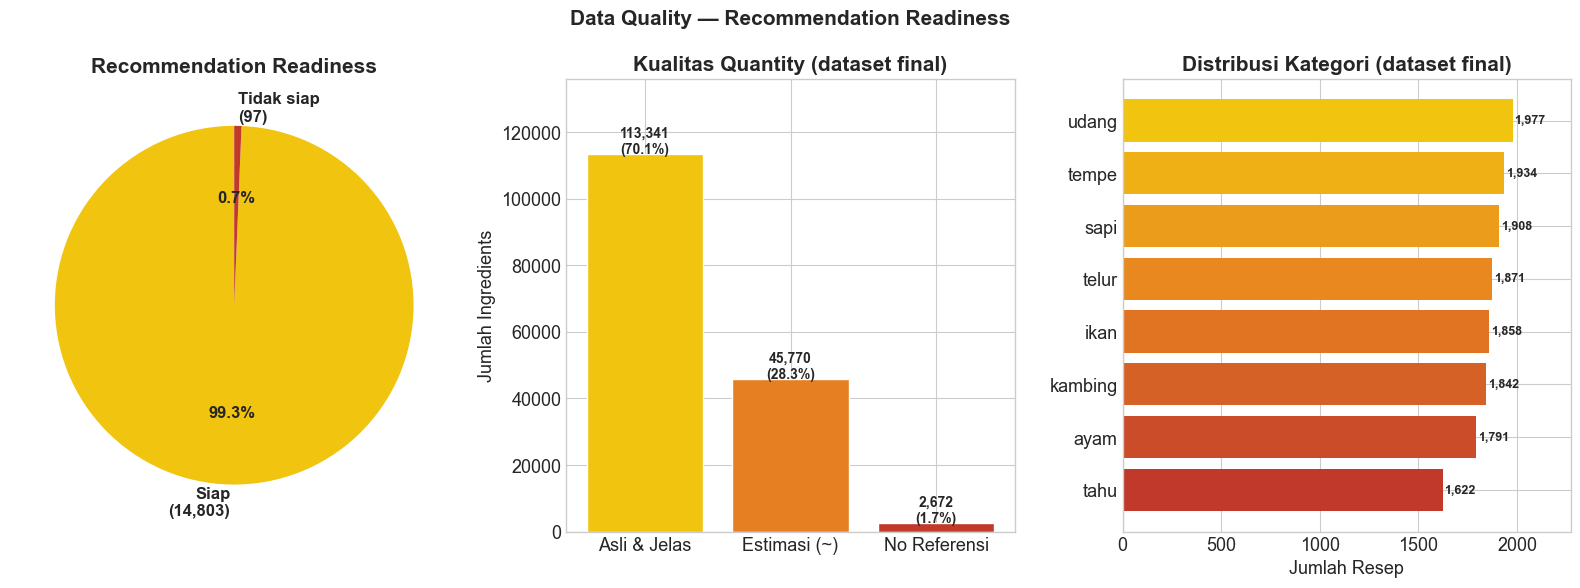

In [23]:
# --- Visualisasi: Readiness dashboard ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Data Quality — Recommendation Readiness', fontsize=15, fontweight='bold')

# 1. Pie: ready vs not
axes[0].pie([len(df_ready), len(df_notready)],
            labels=[f'Siap\n({len(df_ready):,})', f'Tidak siap\n({len(df_notready):,})'],
            colors=[KUNING, MERAH], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Recommendation Readiness')

# 2. Bar: qty quality setelah imputation
qty_labels2 = ['Asli & Jelas', 'Estimasi (~)', 'No Referensi']
qty_vals2   = [clear_r, imputed_r, remain_r]
bars = axes[1].bar(qty_labels2, qty_vals2, color=[KUNING, ORANYE, MERAH], edgecolor='white')
axes[1].set_title('Kualitas Quantity (dataset final)')
axes[1].set_ylabel('Jumlah Ingredients')
for bar, val in zip(bars, qty_vals2):
    pct = val / total_r * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(qty_vals2) * 1.2)

# 3. Bar: category distribution di df_ready
cat_ready = df_ready['Category'].value_counts().sort_values()
n = len(cat_ready)
bars3 = axes[2].barh(cat_ready.index, cat_ready.values,
                     color=[warm_cmap(i/max(n-1,1)) for i in range(n)])
axes[2].set_title('Distribusi Kategori (dataset final)')
axes[2].set_xlabel('Jumlah Resep')
for bar, val in zip(bars3, cat_ready.values):
    axes[2].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[2].set_xlim(0, cat_ready.max() * 1.15)

plt.tight_layout()
plt.savefig('v2_05_readiness.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Text Cleaning — Title & Steps

Yang dibersihkan secara otomatis (aman, low risk):

| Kolom | Fix |
|---|---|
| `Title` & `Title Cleaned` | Hapus emoji, hapus hashtag, `cabe` → `cabai` |
| `Steps` | Hapus emoji, `cabe` → `cabai`, hapus kata penutup informal di akhir kalimat, hapus karakter berulang berlebihan |

Yang **tidak** disentuh (terlalu berisiko salah):
- Singkatan (`bwg`, `dg`, `d olesi`) — edge case terlalu banyak  
- Kata informal di **tengah** kalimat (`"masak hingga matang yaa"`) — tidak bisa pisahkan dari instruksi valid

In [24]:
# --- Cleaning functions ---

EMOJI_RE = re.compile(
    "[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF\U00002702-\U000027B0\U000024C2-\U0001F251"
    "\U0000200d\U0000FE0F\U00002600-\U000026FF\U00002700-\U000027BF"
    "\U00002500-\U00002BEF\U00010000-\U0001FFFF]+",
    flags=re.UNICODE
)

CABE_RE = re.compile(r'\bcabe\b', re.IGNORECASE)

# "by [name]" di akhir judul — hanya kalau bukan "step by step" / "made by"
# Negative lookbehind untuk "step" dan "made"
BY_ATTR_RE = re.compile(r'(?<!step)(?<!made)\s+by\s+\S+(\s+\S+)?$', re.IGNORECASE)

# Kata penutup informal di akhir kalimat / baris
INFORMAL_END_RE = re.compile(
    r'[\s,]*\b(buibu+\w*|moms?|bund[ae]\w*|hayuk\w*|yuk+\w*|'
    r'happy\s+cooking\w*|selamat\s+mencoba\w*|selamat\s+makan\w*|'
    r'semoga\s+bermanfaat\w*|taraa+\w*|ndoweer+\w*|ciuss\w*|'
    r'wkwk+\w*|hehe+\w*|hihi+\w*)\b[\s.!]*$',
    re.IGNORECASE
)

# "Oh iya(a)" / "Oh ya" di awal kalimat → strip
OH_IYA_RE = re.compile(r'^oh\s+iy?a+[,!.\s]*', re.IGNORECASE)

# Karakter berulang 3x+ dalam satu kata → hapus kata itu
REPEATED_CHAR_WORD_RE = re.compile(r'\b\w*([a-zA-Z])\\1{2,}\w*\b')

def title_case(s):
    """Title case tiap kata, aman untuk Indonesian."""
    return ' '.join(w.capitalize() for w in str(s).split())

def clean_title(title, apply_title_case=False):
    if pd.isna(title): return title
    t = EMOJI_RE.sub('', str(title))
    t = re.sub(r'#\S+', '', t)          # hapus hashtag
    t = BY_ATTR_RE.sub('', t)            # hapus "by [name]"
    t = CABE_RE.sub('cabai', t)
    t = re.sub(r'\s{2,}', ' ', t).strip()
    if apply_title_case:
        t = title_case(t)
    return t

def clean_steps(steps_str):
    if pd.isna(steps_str): return steps_str
    lines = str(steps_str).split('\n')
    result = []
    for line in lines:
        line = EMOJI_RE.sub('', line)
        line = CABE_RE.sub('cabai', line)
        line = INFORMAL_END_RE.sub('', line)
        line = OH_IYA_RE.sub('', line)
        line = REPEATED_CHAR_WORD_RE.sub('', line)
        line = re.sub(r'[ \t]{2,}', ' ', line).strip()
        if len(line) >= 5:
            result.append(line)
    return '\n'.join(result)

print("Cleaning functions defined.")
print("Contoh title_case + by removal:")
tests = [
    "Mie Ayam Homemade by suami",
    "Gulai kepala kambing step by step",
    "ayam goreng tepung #simple",
    "Sop Iga Sapi by Ezelea",
    "Tongseng daging sapi by adilly_kitchen",
]
for t in tests:
    print(f"  BEFORE: {t}")
    print(f"  AFTER : {clean_title(t, apply_title_case=True)}")
    print()

Cleaning functions defined.
Contoh title_case + by removal:
  BEFORE: Mie Ayam Homemade by suami
  AFTER : Mie Ayam Homemade By Suami

  BEFORE: Gulai kepala kambing step by step
  AFTER : Gulai Kepala Kambing Step By Step

  BEFORE: ayam goreng tepung #simple
  AFTER : Ayam Goreng Tepung

  BEFORE: Sop Iga Sapi by Ezelea
  AFTER : Sop Iga Sapi

  BEFORE: Tongseng daging sapi by adilly_kitchen
  AFTER : Tongseng Daging Sapi



In [25]:
# --- Apply cleaning ---
# Title: title case + hapus by/emoji/hashtag/cabe
df_ready['Title']         = df_ready['Title'].apply(lambda x: clean_title(x, apply_title_case=True))
# Title Cleaned: lowercase (untuk model), hapus by/emoji/hashtag/cabe tapi JANGAN title case
df_ready['Title Cleaned'] = df_ready['Title Cleaned'].apply(lambda x: clean_title(x, apply_title_case=False))
# Steps: hapus emoji, cabe→cabai, informal end
df_ready['Steps']         = df_ready['Steps'].apply(clean_steps)

# --- Verifikasi ---
orig_df = pd.read_csv('Indonesian_Food_Recipes_Cleaned_v3.csv')

by_before = orig_df['Title'].str.contains(r'(?<!step)(?<!made)\s+by\s+', case=False, na=False, regex=True).sum()
by_after  = df_ready['Title'].str.contains(r'(?<!step)(?<!made)\s+by\s+', case=False, na=False, regex=True).sum()

cabe_title_before = orig_df['Title Cleaned'].str.contains(r'\bcabe\b', case=False, na=False).sum()
cabe_title_after  = df_ready['Title Cleaned'].str.contains(r'\bcabe\b', case=False, na=False).sum()

emoji_steps_before = orig_df['Steps'].apply(lambda x: bool(EMOJI_RE.search(str(x)))).sum()
emoji_steps_after  = df_ready['Steps'].apply(lambda x: bool(EMOJI_RE.search(str(x)))).sum()

cabe_steps_before = orig_df['Steps'].str.contains(r'\bcabe\b', case=False, na=False).sum()
cabe_steps_after  = df_ready['Steps'].str.contains(r'\bcabe\b', case=False, na=False).sum()

print("=== Hasil Cleaning ===")
print(f"  Title — 'by [name]' dihapus  : {by_before} → {by_after}")
print(f"  Title — Title Case diterapkan: contoh → '{df_ready['Title'].iloc[0]}'")
print(f"  Title Cleaned — 'cabe'       : {cabe_title_before} → {cabe_title_after}")
print(f"  Steps — emoji                : {emoji_steps_before} → {emoji_steps_after}")
print(f"  Steps — 'cabe'               : {cabe_steps_before} → {cabe_steps_after}")

=== Hasil Cleaning ===
  Title — 'by [name]' dihapus  : 26 → 3
  Title — Title Case diterapkan: contoh → 'Ayam Woku Manado'
  Title Cleaned — 'cabe'       : 271 → 0
  Steps — emoji                : 119 → 0
  Steps — 'cabe'               : 4164 → 0


In [26]:
# --- Before vs After untuk beberapa contoh ---
print("=== BEFORE vs AFTER (Steps) ===\n")

samples = [0, 2, 6]  # Ayam Woku, Nugget Ayam, Ayam goreng tepung simple
orig_steps = orig_df['Steps']

for idx in samples:
    title    = df_ready.iloc[idx]['Title']
    before   = str(orig_steps.iloc[idx])
    after    = str(df_ready.iloc[idx]['Steps'])
    
    before_lines = [l.strip() for l in before.split('\n') if l.strip()]
    after_lines  = [l.strip() for l in after.split('\n')  if l.strip()]
    
    print(f"Resep: {title}")
    print(f"  {'BEFORE':<65}  AFTER")
    print(f"  {'-'*65}  {'-'*65}")
    for b, a in zip(before_lines[:5], after_lines[:5]):
        changed = ' ← ' if b != a else ''
        print(f"  {b[:65]:<65}  {a[:65]}{changed}")
    print()

=== BEFORE vs AFTER (Steps) ===

Resep: Ayam Woku Manado
  BEFORE                                                             AFTER
  -----------------------------------------------------------------  -----------------------------------------------------------------
  1) Cuci bersih ayam dan tiriskan. Lalu peras jeruk nipis (kalo ga  1) Cuci bersih ayam dan tiriskan. Lalu peras jeruk nipis (kalo ga
  2) Goreng ayam tersebut setengah matang, lalu tiriskan             2) Goreng ayam tersebut setengah matang, lalu tiriskan
  3) Haluskan bumbu menggunakan blender. Bawang merah, bawang putih  3) Haluskan bumbu menggunakan blender. Bawang merah, bawang putih ← 
  4) Setelah bumbu di haluskan barulah di tumis. Jangan lupa sereh   4) Setelah bumbu di haluskan barulah di tumis. Jangan lupa sereh 
  5) Masukan ayam yang sudah di goreng setengah matang ke dalam bum  5) Masukan ayam yang sudah di goreng setengah matang ke dalam bum

Resep: Ayam Cabai Kawin
  BEFORE                                 

In [27]:
# --- Perbandingan kuantitatif ketiga pendekatan ---
print('=== Perbandingan Pendekatan ===')
print()

# Pendekatan A: jumlah bahan dengan qty jelas
a_coverage = df['qty_coverage_pct'].mean()
a_parseable = (df['qty_coverage_pct'] >= 50).sum()
print(f'Pendekatan A (Structured Parsing):')
print(f'  Rata-rata qty coverage          : {a_coverage:.1f}%')
print(f'  Resep dengan coverage >= 50%    : {a_parseable:,} ({a_parseable/len(df)*100:.1f}%)')
print(f'  Total bahan berhasil di-parse   : {total_clear:,} dari {total_ing:,} ({total_clear/total_ing*100:.1f}%)')

print()

# Pendekatan B: binary presence — ukur unique ingredients
all_ings = []
for row in df['Ingredients Cleaned'].dropna():
    all_ings.extend([i.strip() for i in str(row).split(',') if i.strip()])
unique_ings = len(set(all_ings))
top10 = Counter(all_ings).most_common(10)
print(f'Pendekatan B (Binary Presence Matrix):')
print(f'  Unique ingredients (fitur)      : {unique_ings:,}')
print(f'  Setelah filter discriminative   : ~{df["discriminative_count"].sum():,} entri berguna')
print(f'  Top 5 ingredients paling umum   : {", ".join([x[0] for x in top10[:5]])}')

print()
print(f'Pendekatan C (Normalized Quantity):')
print(f'  Bahan dengan satuan berat       : {sum(1 for i in df["ingredients_parsed"].explode() if isinstance(i, dict) and i.get("unit") in ["gram","kg","ons"]):,}')
print(f'  Bahan dengan satuan volume      : {sum(1 for i in df["ingredients_parsed"].explode() if isinstance(i, dict) and i.get("unit") in ["ml","liter","sdm","sdt","gelas","cup"]):,}')
print(f'  Bahan dengan satuan hitung      : {sum(1 for i in df["ingredients_parsed"].explode() if isinstance(i, dict) and i.get("unit") in ["siung","buah","biji","butir","lembar","batang","ikat","ekor"]):,}')
print(f'  → Normalisasi lintas satuan TIDAK feasible (berat ≠ volume ≠ hitung)')

=== Perbandingan Pendekatan ===

Pendekatan A (Structured Parsing):
  Rata-rata qty coverage          : 75.0%
  Resep dengan coverage >= 50%    : 13,147 (88.2%)
  Total bahan berhasil di-parse   : 3,374 dari 162,624 (2.1%)

Pendekatan B (Binary Presence Matrix):
  Unique ingredients (fitur)      : 10,671
  Setelah filter discriminative   : ~127,236 entri berguna
  Top 5 ingredients paling umum   : bawang putih, garam, bawang merah, cabai rawit, jahe

Pendekatan C (Normalized Quantity):
  Bahan dengan satuan berat       : 10,023
  Bahan dengan satuan volume      : 27,018
  Bahan dengan satuan hitung      : 51,787
  → Normalisasi lintas satuan TIDAK feasible (berat ≠ volume ≠ hitung)


## 6. Kesimpulan & Rekomendasi

In [28]:
print('=' * 65)
print('RINGKASAN EDA v2 — Indonesian Food Recipes')
print('=' * 65)

print(f'''
DATASET AWAL : {len(df):,} resep
DATASET FINAL: {len(df_ready):,} resep ({len(df_ready)/len(df)*100:.1f}% siap untuk rekomendasi)

1. STATISTICAL IMPUTATION (Quantity)
   - Resolved: {clear_r+imputed_r:,}/{total_r:,} quantity ({(clear_r+imputed_r)/total_r*100:.1f}%)
   - Sisa tanpa referensi: {remain_r:,} ({remain_r/total_r*100:.1f}%)

2. DATA QUALITY CHECKS
   - Duplikat (title+ing) : {df.duplicated(subset=["Title Cleaned","Ingredients Cleaned"]).sum()}
   - Resep < 3 bahan      : {(df["_ing_count"] < 3).sum()} dibuang
   - Category balance     : {df["Category"].nunique()} kategori, rasio {df["Category"].value_counts().max()/df["Category"].value_counts().min():.1f}x

3. TEXT CLEANING (Title & Steps)
   - Title Cleaned : hapus emoji, hashtag, cabe→cabai
   - Steps         : hapus emoji, cabe→cabai, hapus kata penutup informal

KOLOM FINAL CSV (11 kolom):
   Title, Ingredients, Steps, Loves, URL, Category,
   Title Cleaned, Total Ingredients, Ingredients Cleaned,
   Total Steps, Quantity
''')

# ============================================================
# HAPUS BAHAN NON-FOOD dari Ingredients Cleaned & Quantity
# ============================================================
def remove_non_food_items(row):
    """Hapus bahan non-food dari Ingredients Cleaned dan Quantity secara serentak."""
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',') if i.strip()]
    qtys = [q.strip() for q in str(row['Quantity']).split(',') if q.strip()]
    # Pad jika panjang tidak sama
    if len(qtys) < len(ings):
        qtys += ['-'] * (len(ings) - len(qtys))
    clean_ings, clean_qtys = [], []
    for ing, qty in zip(ings, qtys):
        if ing not in NON_FOOD_EXACT and not NON_FOOD_PATTERN.search(ing):
            clean_ings.append(ing)
            clean_qtys.append(qty)
    return ', '.join(clean_ings), ', '.join(clean_qtys)

before_clean = len(df_ready)
cleaned = df_ready.apply(remove_non_food_items, axis=1, result_type='expand')
df_ready = df_ready.copy()
df_ready['Ingredients Cleaned'] = cleaned[0]
df_ready['Quantity']            = cleaned[1]

# Drop resep yang setelah pembersihan jadi < 3 bahan
df_ready['_ing_count_clean'] = df_ready['Ingredients Cleaned'].apply(
    lambda x: len([i for i in str(x).split(',') if i.strip()])
)
dropped_non_food = (df_ready['_ing_count_clean'] < 3).sum()
df_ready = df_ready[df_ready['_ing_count_clean'] >= 3].drop(columns=['_ing_count_clean'])

print(f'Non-food cleaning:')
print(f'  Bahan non-food dihapus dari list ingredients')
print(f'  Resep gugur (< 3 bahan setelah cleaning): {dropped_non_food}')
print(f'  Dataset final: {len(df_ready):,} resep')

# Simpan final CSV
cols_final = ['Title','Ingredients','Steps','Loves','URL','Category',
              'Title Cleaned','Total Ingredients','Ingredients Cleaned',
              'Total Steps','Quantity']
df_ready[cols_final].to_csv(
    'Indonesian_Food_Recipes_Cleaned_v4.csv', index=False
)
print(f'\nDisimpan: Indonesian_Food_Recipes_Cleaned_v4.csv')
print(f'Shape  : {df_ready[cols_final].shape}')

print('\nContoh 2 baris:')
for _, row in df_ready[cols_final].head(2).iterrows():
    ings = [i.strip() for i in str(row['Ingredients Cleaned']).split(',')]
    qtys = [q.strip() for q in str(row['Quantity']).split(',')]
    print(f"\n  [{row['Title']}]")
    for ing, qty in zip(ings[:5], qtys[:5]):
        print(f'    {ing:<28} {qty}')

RINGKASAN EDA v2 — Indonesian Food Recipes

DATASET AWAL : 14,900 resep
DATASET FINAL: 14,803 resep (99.3% siap untuk rekomendasi)

1. STATISTICAL IMPUTATION (Quantity)
   - Resolved: 159,111/161,783 quantity (98.3%)
   - Sisa tanpa referensi: 2,672 (1.7%)

2. DATA QUALITY CHECKS
   - Duplikat (title+ing) : 0
   - Resep < 3 bahan      : 77 dibuang
   - Category balance     : 8 kategori, rasio 1.2x

3. TEXT CLEANING (Title & Steps)
   - Title Cleaned : hapus emoji, hashtag, cabe→cabai
   - Steps         : hapus emoji, cabe→cabai, hapus kata penutup informal

KOLOM FINAL CSV (11 kolom):
   Title, Ingredients, Steps, Loves, URL, Category,
   Title Cleaned, Total Ingredients, Ingredients Cleaned,
   Total Steps, Quantity

Disimpan: Indonesian_Food_Recipes_Cleaned_v4.csv
Shape  : (14803, 11)

Contoh 2 baris:

  [Ayam Woku Manado]
    ayam kampung                 1 ekor
    jeruk nipis                  2 buah
    garam                        2 sdm
    kunyit                       3 ruas
    

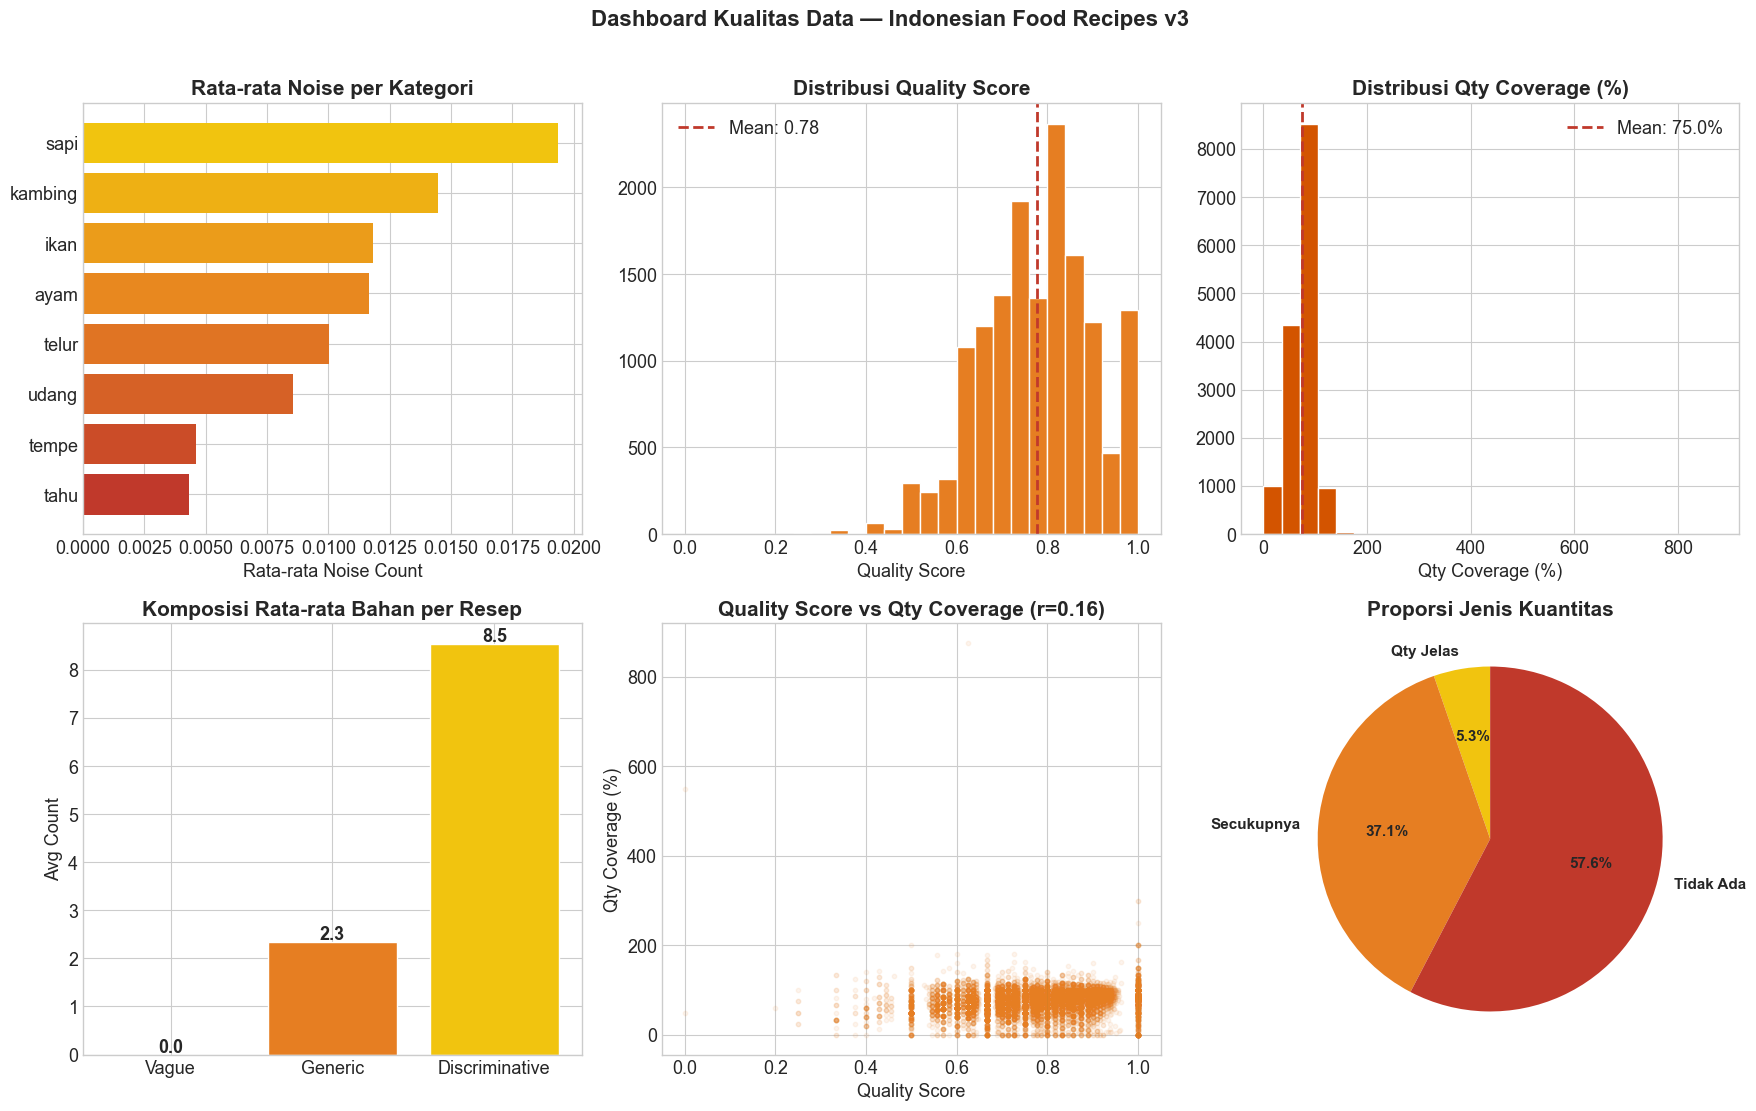

In [29]:
# --- Dashboard ringkasan semua kolom baru ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Dashboard Kualitas Data — Indonesian Food Recipes v3', fontsize=16, fontweight='bold', y=1.01)

# 1. Noise per kategori
cat_noise = df.groupby('Category')['total_noise_count'].mean().sort_values()
n = len(cat_noise)
axes[0,0].barh(cat_noise.index, cat_noise.values, color=[warm_cmap(i/max(n-1,1)) for i in range(n)])
axes[0,0].set_title('Rata-rata Noise per Kategori')
axes[0,0].set_xlabel('Rata-rata Noise Count')

# 2. Quality score histogram
axes[0,1].hist(df['quality_score'].dropna(), bins=25, color=ORANYE, edgecolor='white')
axes[0,1].axvline(df['quality_score'].mean(), color=MERAH, linestyle='--', linewidth=2,
                  label=f"Mean: {df['quality_score'].mean():.2f}")
axes[0,1].set_title('Distribusi Quality Score')
axes[0,1].set_xlabel('Quality Score')
axes[0,1].legend()

# 3. Qty coverage histogram
axes[0,2].hist(df['qty_coverage_pct'].dropna(), bins=25, color=ORANYE_TUA, edgecolor='white')
axes[0,2].axvline(df['qty_coverage_pct'].mean(), color=MERAH, linestyle='--', linewidth=2,
                  label=f"Mean: {df['qty_coverage_pct'].mean():.1f}%")
axes[0,2].set_title('Distribusi Qty Coverage (%)')
axes[0,2].set_xlabel('Qty Coverage (%)')
axes[0,2].legend()

# 4. Komposisi rata-rata bahan
avg_v = [df['vague_count'].mean(), df['generic_count'].mean(), df['discriminative_count'].mean()]
axes[1,0].bar(['Vague', 'Generic', 'Discriminative'], avg_v,
              color=[MERAH, ORANYE, KUNING], edgecolor='white')
axes[1,0].set_title('Komposisi Rata-rata Bahan per Resep')
axes[1,0].set_ylabel('Avg Count')
for i, v in enumerate(avg_v):
    axes[1,0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontweight='bold')

# 5. Scatter: quality_score vs qty_coverage
axes[1,1].scatter(df['quality_score'], df['qty_coverage_pct'],
                  alpha=0.08, s=10, color=ORANYE)
axes[1,1].set_xlabel('Quality Score')
axes[1,1].set_ylabel('Qty Coverage (%)')
r = df[['quality_score','qty_coverage_pct']].corr().iloc[0,1]
axes[1,1].set_title(f'Quality Score vs Qty Coverage (r={r:.2f})')

# 6. Pie: proporsi qty types
axes[1,2].pie([total_clear, total_vague, total_none],
              labels=['Qty Jelas', 'Secukupnya', 'Tidak Ada'],
              colors=[KUNING, ORANYE, MERAH],
              autopct='%1.1f%%', startangle=90,
              textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1,2].set_title('Proporsi Jenis Kuantitas')

plt.tight_layout()
plt.savefig('v2_04_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()